<a href="https://colab.research.google.com/github/matildacoray/portafolio/blob/etapa-1/Portafolio_y_examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uso de la api de Banco Mundial
La API se ofrece de forma similar a una API REST, aceptando solicitudes en forma de cadena de consulta de URL como solicitudes HTTP GET. La cadena de consulta de la URL determina:

· qué se debe buscar

· qué se debe devolver por cada registro coincidente

· cómo se formatea lo que se devuelve (como JSON o XML)  

In [15]:
#Instalar biblioteca
%pip install wbgapi

Para empezar, se instala la librería wbgapi, la cual deja entrar de forma directa a la información libre del Banco Mundial (cosas de economía, sociedad, medio ambiente, etcétera) usando Python.

In [16]:
import wbgapi as wb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

Estas bibliotecas se usan para manipular datos (pandas), graficar (matplotlib, seaborn, plotly) y conectarse a la API del Banco Mundial (wbgapi).

In [17]:
from google.colab import drive
from datetime import datetime
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/CDE/')

import my_func as fn



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Se usa Google Drive para guardar o cargar archivos, especialmente funciones auxiliares ya escritas por el profesor o el estudiante (my_func.py).
Se agrega la ruta del archivo de funciones (my_func.py) y se importa como fn, para poder usar funciones personalizadas como la descarga por bloques (descargar_en_chunks).

In [18]:
# Indicadores a consultar
indicadores_wb = {
    "NY.GDP.MKTP.PP.KD": "GDP, PPP (constant 2021 international $)",
    "SP.POP.GROW": "Population growth (annual %)",
    "SP.POP.TOTL": "Population, total",
    "SP.POP.TOTL.FE.IN": "Population, female",
    "SP.POP.TOTL.FE.ZS": "Population, female (% of total population)",
    "SP.POP.TOTL.MA.IN": "Population, male",
    "SP.POP.TOTL.MA.ZS": "Population, male (% of total population)",
    "SP.URB.GROW": "Urban population growth (annual %)",
    "SP.URB.TOTL": "Urban population",
    "SP.URB.TOTL.IN.ZS": "Urban population (% of total population)",
    "SP.RUR.TOTL": "Rural population",
    "SP.RUR.TOTL.ZG": "Rural population growth (annual %)",
    "SP.RUR.TOTL.ZS": "Rural population (% of total population)",
    "SL.TLF.TOTL.IN": "Labor force, total",
    "SL.TLF.TOTL.FE.ZS": "Labor force, female (% of total labor force)",
    "SL.UEM.TOTL.FE.NE.ZS": "Unemployment, female (% of female labor force) (national estimate)",
    "SL.UEM.TOTL.FE.ZS": "Unemployment, female (% of female labor force) (modeled ILO estimate)",
    "SL.UEM.TOTL.MA.NE.ZS": "Unemployment, male (% of male labor force) (national estimate)",
    "SL.UEM.TOTL.MA.ZS": "Unemployment, male (% of male labor force) (modeled ILO estimate)",
    "SL.UEM.TOTL.NE.ZS": "Unemployment, total (% of total labor force) (national estimate)",
    "SL.UEM.TOTL.ZS": "Unemployment, total (% of total labor force) (modeled ILO estimate)",
    "FP.CPI.TOTL.ZG": "Inflation, consumer prices (annual %)",
    "GC.TAX.EXPT.CN": "Taxes on exports (current LCU)",
    "GC.TAX.EXPT.ZS": "Taxes on exports (% of tax revenue)",
    "NE.EXP.GNFS.KD.ZG": "Exports of goods and services (annual % growth)",
    "NE.EXP.GNFS.KN": "Exports of goods and services (constant LCU)",
    "NE.EXP.GNFS.ZS": "Exports of goods and services (% of GDP)",
    "NV.AGR.TOTL.CD": "Agriculture, forestry, and fishing, value added (current US$)",
    "NV.AGR.TOTL.CN": "Agriculture, forestry, and fishing, value added (current LCU)",
    "NV.IND.MANF.CD": "Manufacturing, value added (current US$)",
    "NV.IND.MANF.CN": "Manufacturing, value added (current LCU)",
    "NV.IND.TOTL.CD": "Industry (including construction), value added (current US$)",
    "NV.IND.TOTL.CN": "Industry (including construction), value added (current LCU)",
    "NV.SRV.TOTL.CD": "Services, value added (current US$)",
    "NV.SRV.TOTL.CN": "Services, value added (current LCU)",
    "GE.EST": "Government Effectiveness: Estimate",
    "NE.CON.GOVT.KN": "General government final consumption expenditure (constant LCU)",
    "NE.CON.GOVT.ZS": "General government final consumption expenditure (% of GDP)",
    "NE.CON.PRVT.CD": "Households and NPISHs Final consumption expenditure (current US$)",
    "NE.CON.PRVT.CN": "Households and NPISHs Final consumption expenditure (current LCU)",
    "GC.DOD.TOTL.CN": "Central government debt, total (current LCU)",
    "GC.DOD.TOTL.GD.ZS": "Central government debt, total (% of GDP)",
    "BM.KLT.DINV.CD.WD": "Foreign direct investment, net outflows (BoP, current US$)",
    "BX.KLT.DINV.WD.GD.ZS": "Foreign direct investment, net inflows (% of GDP)",
    "EG.ELC.LOSS.ZS": "Electric power transmission and distribution losses (% of output)",
    "EG.USE.ELEC.KH.PC": "Electric power consumption (kWh per capita)",
    "EN.GHG.CO2.IP.MT.CE.AR5": "Carbon dioxide emissions from Industrial Processes (Mt CO2e)",
    "SE.PRM.NENR": "School enrollment, primary (% net)",
    "SE.PRM.NENR.FE": "School enrollment, primary, female (% net)",
    "SE.PRM.NENR.MA": "School enrollment, primary, male (% net)",
    "SE.SEC.ENRR": "School enrollment, secondary (% gross)",
    "SE.SEC.ENRR.FE": "School enrollment, secondary, female (% gross)",
    "SE.SEC.ENRR.MA": "School enrollment, secondary, male (% gross)",
    "SE.TER.ENRR": "School enrollment, tertiary (% gross)",
    "SE.TER.ENRR.FE": "School enrollment, tertiary, female (% gross)",
    "SE.TER.ENRR.MA": "School enrollment, tertiary, male (% gross)",
    "SP.DYN.LE00.IN": "Life expectancy at birth, total (years)",
    "SP.DYN.LE00.FE.IN": "Life expectancy at birth, female (years)",
    "SP.DYN.LE00.MA.IN": "Life expectancy at birth, male (years)",
    "EG.CFT.ACCS.ZS": "Access to clean fuels and technologies for cooking (% of population)",
    "EG.CFT.ACCS.RU.ZS": "Access to clean fuels and technologies for cooking, rural (% of rural population)",
    "EG.CFT.ACCS.UR.ZS": "Access to clean fuels and technologies for cooking, urban (% of urban population)",
    "IT.NET.USER.FE.ZS": "Individuals using the Internet, female (% of female population)",
    "IT.NET.USER.MA.ZS": "Individuals using the Internet, male (% of male population)",
    "IT.NET.USER.ZS": "Individuals using the Internet (% of population)",
}

Se define un diccionario con los indicadores de interés que se van a consultar. Esto permite organizar y personalizar la descarga de datos relevantes para el análisis socioeconómico

In [19]:
paises_wb_raw = fn.descargar_en_chunks(indicadores=indicadores_wb,años=2023, chunk_size = 15)

Descargando bloque 1: ['NY.GDP.MKTP.PP.KD', 'SP.POP.GROW', 'SP.POP.TOTL', 'SP.POP.TOTL.FE.IN', 'SP.POP.TOTL.FE.ZS', 'SP.POP.TOTL.MA.IN', 'SP.POP.TOTL.MA.ZS', 'SP.URB.GROW', 'SP.URB.TOTL', 'SP.URB.TOTL.IN.ZS', 'SP.RUR.TOTL', 'SP.RUR.TOTL.ZG', 'SP.RUR.TOTL.ZS', 'SL.TLF.TOTL.IN', 'SL.TLF.TOTL.FE.ZS']
Descargando bloque 2: ['SL.UEM.TOTL.FE.NE.ZS', 'SL.UEM.TOTL.FE.ZS', 'SL.UEM.TOTL.MA.NE.ZS', 'SL.UEM.TOTL.MA.ZS', 'SL.UEM.TOTL.NE.ZS', 'SL.UEM.TOTL.ZS', 'FP.CPI.TOTL.ZG', 'GC.TAX.EXPT.CN', 'GC.TAX.EXPT.ZS', 'NE.EXP.GNFS.KD.ZG', 'NE.EXP.GNFS.KN', 'NE.EXP.GNFS.ZS', 'NV.AGR.TOTL.CD', 'NV.AGR.TOTL.CN', 'NV.IND.MANF.CD']
Descargando bloque 3: ['NV.IND.MANF.CN', 'NV.IND.TOTL.CD', 'NV.IND.TOTL.CN', 'NV.SRV.TOTL.CD', 'NV.SRV.TOTL.CN', 'GE.EST', 'NE.CON.GOVT.KN', 'NE.CON.GOVT.ZS', 'NE.CON.PRVT.CD', 'NE.CON.PRVT.CN', 'GC.DOD.TOTL.CN', 'GC.DOD.TOTL.GD.ZS', 'BM.KLT.DINV.CD.WD', 'BX.KLT.DINV.WD.GD.ZS', 'EG.ELC.LOSS.ZS']
Descargando bloque 4: ['EG.USE.ELEC.KH.PC', 'EN.GHG.CO2.IP.MT.CE.AR5', 'SE.PRM.NENR', '

Se utiliza una función personalizada para descargar los indicadores seleccionados por bloques (para evitar errores por exceso de columnas). Se usa el año 2023 para tener datos actualizados.

Analisis exploratorio de datos

In [20]:
paises_wb_raw.tail(5)

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
261,CEB,Central Europe and the Baltics,4.218704e+12,45.670155,49100893.0,0.111693,100183707.0,51639515.0,51.544825,48544192.0,...,80.939987,56.712559,81.624607,77.896625,74.354109,100.000000,100.000000,NaN,NaN,NaN
262,CSS,Caribbean small states,1.338577e+11,43.965332,1919128.0,0.501131,4519904.0,2293907.0,50.751230,2225997.0,...,NaN,NaN,76.456921,73.171645,69.986624,95.267180,98.879872,NaN,NaN,NaN
263,ARB,Arab World,8.097600e+12,19.141318,132483437.0,2.255866,482105978.0,232702770.0,48.267971,249403208.0,...,34.757931,31.807100,74.418910,72.444678,70.619437,77.839625,93.857501,NaN,NaN,NaN
264,AFW,Africa Western and Central,2.992692e+12,46.355771,212022202.0,2.386204,509398589.0,252899429.0,49.646669,256499160.0,...,NaN,NaN,59.997102,58.855722,57.752356,6.004144,45.206379,33.0,44.0,38.5
265,AFE,Africa Eastern and Southern,3.065002e+12,47.278292,288476515.0,2.519167,750491370.0,379019549.0,50.502852,371471821.0,...,NaN,NaN,67.914632,65.146154,62.395419,10.288154,41.289974,24.8,30.9,27.8


In [21]:
#Seleccionar solamente paises usando codigo ISO
table_dict = vars(wb.economy.info())
df_paises = pd.DataFrame(table_dict.get('items'))
iso_list = list(df_paises[df_paises['aggregate']==False]['id'])

In [22]:
#Seleccionar solamente paises
paises_wb_raw = paises_wb_raw[paises_wb_raw['country'].isin(iso_list)].reset_index(drop = True)

Los datos descargados incluyen tanto países como agregados (regiones, continentes). Aquí se filtran únicamente los países reales usando su código ISO para tener un análisis representativo.

Una vez seleccionado solamente los paises procederemos al analisis exploratorio de los datos

In [23]:
paises_wb_raw.tail()

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
193,AGO,Angola,3.229678e+11,49.450638,15430003.0,3.080655,36749906.0,18568216.0,50.525887,18181690.0,...,9.933616,10.165600,67.144,64.617,62.099,8.4,75.0,NaN,NaN,44.7581
194,AND,Andorra,5.225828e+09,NaN,NaN,1.433748,80856.0,39502.0,48.854754,41354.0,...,68.003820,57.193764,86.107,84.041,82.100,100.0,100.0,NaN,NaN,95.4456
195,DZA,Algeria,6.998184e+11,16.830056,13174228.0,1.498976,46164219.0,22614984.0,48.988123,23549235.0,...,67.258843,44.258295,77.696,76.261,74.895,99.1,99.9,NaN,NaN,76.9081
196,ALB,Albania,4.944312e+10,44.994435,1210263.0,-1.543108,2414095.0,1220548.0,50.559226,1193547.0,...,77.031527,52.749937,81.446,79.602,77.728,72.5,95.2,81.7239,84.59,83.1356
197,AFG,Afghanistan,8.223848e+10,6.846247,8866507.0,2.135594,41454761.0,20530683.0,49.525513,20924078.0,...,NaN,NaN,67.536,66.035,64.467,20.4,87.0,NaN,NaN,17.7089


Analisis descriptivos

In [25]:
paises_wb_raw.describe()

,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,SP.POP.TOTL.MA.ZS,SP.RUR.TOTL,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
count,1.980000e+02,173.000000,1.730000e+02,198.000000,1.980000e+02,1.980000e+02,198.000000,1.980000e+02,198.000000,1.980000e+02,...,122.000000,122.000000,198.000000,198.000000,198.000000,182.000000,182.000000,57.000000,57.000000,177.000000
mean,8.388712e+11,41.898361,2.076029e+07,1.152752,3.999611e+07,1.987776e+07,49.973491,2.011836e+07,50.026509,1.709937e+07,...,60.958578,45.456089,76.119303,73.476060,70.910354,62.271154,78.501099,87.190260,88.240505,72.290555
std,3.129922e+12,9.018596,7.637237e+07,1.576210,1.484957e+08,7.252840e+07,2.993389,7.598056e+07,2.993389,7.663858e+07,...,35.784689,28.107669,7.221813,7.085527,7.104323,41.324522,32.394985,13.774667,12.542169,24.224349
min,5.705451e+07,6.846247,3.361400e+04,-8.423008,9.816000e+03,4.795000e+03,28.483741,5.021000e+03,45.079120,0.000000e+00,...,4.663074,2.806122,54.743000,54.462000,53.195000,0.000000,0.100000,16.697100,19.497300,11.078400
25%,2.586691e+10,40.069279,1.210263e+06,0.282878,1.373786e+06,6.876850e+05,49.651875,6.826450e+05,48.810555,4.134135e+05,...,30.014082,20.436952,70.733000,67.713000,65.379000,11.062500,69.650000,84.786500,86.108800,58.278900
50%,8.596764e+10,45.081945,4.220673e+06,1.112108,7.335048e+06,3.672054e+06,50.329281,3.560820e+06,49.670719,1.983892e+06,...,63.036400,44.203554,77.486500,74.292890,70.666000,84.150000,97.600000,89.829000,90.538300,81.722100
75%,4.615291e+11,47.539585,1.317423e+07,2.088224,2.936413e+07,1.403224e+07,51.189445,1.424457e+07,50.348125,1.024225e+07,...,89.311148,63.348878,81.700000,78.485976,75.803000,100.000000,100.000000,94.406300,95.100000,89.896000
max,3.200488e+13,54.670843,7.746076e+08,6.527050,1.438070e+09,6.961863e+08,54.920880,7.418833e+08,71.516259,9.337718e+08,...,171.113083,159.586578,88.090000,85.706000,84.206000,100.000000,100.000000,100.000000,100.000000,100.000000


Estas líneas permiten visualizar el contenido del DataFrame, sus columnas, tipos de datos y estadísticas básicas como promedio, mínimo, máximo, etc.

In [26]:
paises_wb_raw.isna()

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
0,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
2,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
194,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
195,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
196,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


existen variables con un alto volumen de datos faltantes.
Usaremos la sigueinte regla para el tratamiento de los mismos:


In [27]:
#Condicion booleana
mask_bool = paises_wb_raw.isna().mean()>0.15
#Seleccion columnas nulas
drop_columns = list(paises_wb_raw.isna().mean()[mask_bool].index)
#Eliminar columnas con alto porcentaje de nulos
paises_wb = paises_wb_raw.drop(columns = drop_columns)

Tratamiento de datos faltantes (NaNs):
Se eliminan columnas con más del 15% de datos faltantes, para asegurar la calidad del análisis y evitar resultados sesgados por falta de información

A continuacion revisaremos la cantidad de datos de nuestro DataFrame

In [28]:
print(f'El dataframe contiene {paises_wb.shape[0]} filas y {paises_wb.shape[1]} columnas de las cuales {len(paises_wb.isna().mean()[paises_wb.isna().mean()>0].index)} contienen registros nulos')

El dataframe contiene 198 filas y 41 columnas de las cuales 24 contienen registros nulos


In [29]:
paises_wb.isna().mean()[paises_wb.isna().mean()>0].index

Index(['SL.TLF.TOTL.FE.ZS', 'SL.TLF.TOTL.IN', 'SP.RUR.TOTL.ZG',
       'FP.CPI.TOTL.ZG', 'NE.EXP.GNFS.ZS', 'NV.AGR.TOTL.CD', 'NV.AGR.TOTL.CN',
       'NV.IND.MANF.CD', 'SL.UEM.TOTL.FE.ZS', 'SL.UEM.TOTL.MA.ZS',
       'SL.UEM.TOTL.ZS', 'BM.KLT.DINV.CD.WD', 'BX.KLT.DINV.WD.GD.ZS', 'GE.EST',
       'NV.IND.MANF.CN', 'NV.IND.TOTL.CD', 'NV.IND.TOTL.CN', 'NV.SRV.TOTL.CD',
       'NV.SRV.TOTL.CN', 'EG.CFT.ACCS.ZS', 'EN.GHG.CO2.IP.MT.CE.AR5',
       'EG.CFT.ACCS.RU.ZS', 'EG.CFT.ACCS.UR.ZS', 'IT.NET.USER.ZS'],
      dtype='object')

Identificación de Outliers

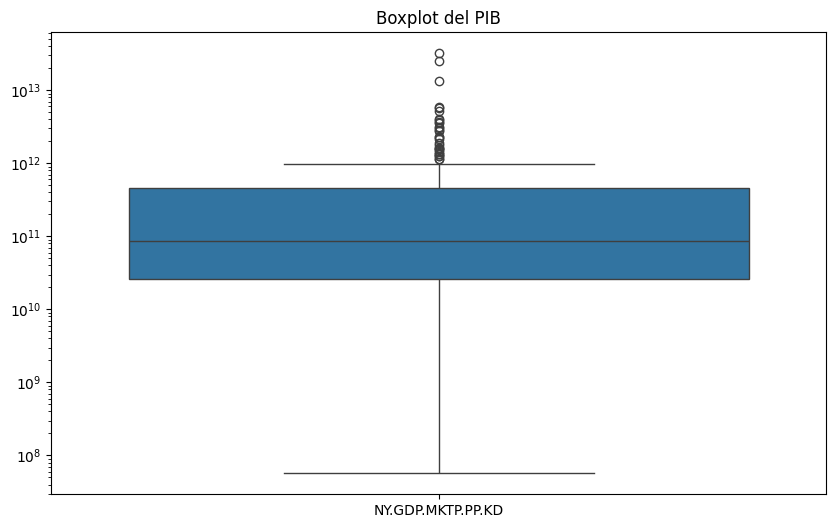

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=paises_wb[['NY.GDP.MKTP.PP.KD']])
plt.yscale('log')
plt.title("Boxplot del PIB")
plt.show()

Se utiliza un boxplot para detectar países con valores extremos de PIB que podrían afectar las visualizaciones y análisis posteriores.

Analisis: Se empleó un diagrama de caja para estudiar cómo se reparte el Producto Interno Bruto (PIB) entre las distintas naciones. El dibujo muestra que la repartición es bastante desigual, con varios puntos muy altos (valores atípicos) situados por encima del borde superior de la caja. Esto sugiere que hay algunas naciones con un PIB considerablemente superior al de la mayoría, algo lógico si pensamos en economías grandes como Estados Unidos, China o Alemania.
Además, si usamos una escala de logaritmos, podemos ver mejor la variación completa, porque con la escala normal la mayor parte de la información se amontonaba cerca de la parte de abajo.
Este modo de ver las cosas ayuda a identificar esos valores extremos que podrían falsear estudios futuros (como PCA o métodos de clasificación), así que es clave pensar en cómo manejarlos o qué efecto tienen.

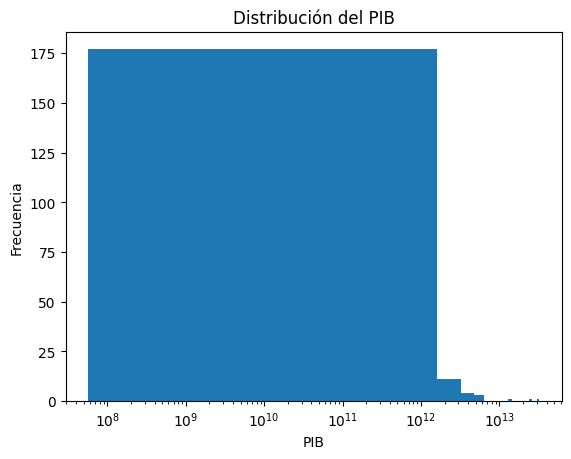

In [37]:
plt.hist(paises_wb['NY.GDP.MKTP.PP.KD'], bins=20)
plt.xscale('log')
plt.title("Distribución del PIB")
plt.xlabel("PIB")
plt.ylabel("Frecuencia")
plt.show()

Visualización de distribución del PIB:
El histograma permite visualizar cómo se distribuyen los valores del PIB entre los países, identificando posibles sesgos o agrupamientos.

Analisis: El diagrama ilustra cómo se reparte el Producto Interno Bruto entre las naciones, empleando una escala logarítmica en el eje horizontal. Se recurre a esta escala porque las cifras del PIB difieren enormemente de una nación a otra algunas poseen ingresos muy reducidos y otras sumamente elevados, lo que puede hacer que una escala normal falsee la presentación visual.

Al usar la escala logarítmica:

- La inclinación de la repartición se suaviza, facilitando apreciar las variaciones entre estados.

- Se percibe que la mayor parte de las naciones cuenta con un PIB bastante modesto, formando un conjunto en el lado izquierdo de la gráfica.

- Hay pocos países ostenta un PIB altísimo, situados bien a la derecha (si bien no resaltan mucho sin retocar los ejes o aplicar intervalos logarítmicos, algo que no se efectuó acá puesto que no fue solicitado por el catedrático).

Esta representación gráfica sirve para comprender el reparto de la prosperidad entre países y para identificar si la economía se concentra en unos pocos.

In [32]:
fig = px.choropleth(paises_wb,
                    locations = "country",
                    color = "NY.GDP.MKTP.PP.KD",
                    hover_name = "Country",
                    color_continuous_scale = px.colors.sequential.Plasma,
                    title = "Mapa del PIB por país")
fig.show()

Mapa de PIB por país:
Se crea un mapa interactivo donde el color representa el nivel de PIB de cada país. Esto permite visualizar diferencias regionales de manera intuitiva.

Analisis: Este mapa interactivo muestra la cantidad del producto interno bruto por nación usando una gama de colores. Se aplicó una progresión de color constante (Plasma) con el siguiente esquema:

- Las tonalidades profundas (azules o moradas) señalan a las naciones con un PIB menor.

- Las tonalidades vivas (anaranjadas o amarillas) señalan a los países con un PIB elevado.

- Naciones como China, Estados Unidos e India sobresalen con los tonos más intensos, señalando que poseen los productos internos brutos más grandes globalmente.

- Una gran extensión de África, la región de América Latina y ciertas zonas de Asia aparecen en matices oscuros, reflejando montos de PIB más reducidos.

Es evidente una disparidad económica a nivel mundial, ya que la prosperidad se concentra en un número reducido de estados.

Para qué sirve este diagrama:

Esta forma de mostrar información es bastante práctica para:

Contrastar el PIB entre distintos países de manera gráfica y sencilla.

Identificar tendencias espaciales o zonales en cómo se reparte el PIB.

Ayudar en la toma de decisiones o en estudios posteriores sobre economía, avance o disparidad.

In [33]:
paises_wb['GDP_Group'] = pd.qcut(paises_wb['NY.GDP.MKTP.PP.KD'], q=5,
                                 labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'])

Clasificación de países según PIB (quintiles): Se agrupan los países en cinco niveles de PIB (quintiles), lo que permite hacer comparaciones entre grupos socioeconómicos similares, facilitando el análisis multivariable.